This Notebook is testing the fundamentals of QEM (Error-Mitigation) with these goals in mind:
- Trying to understand how stim can be used for QEM
- Trying to use prob. error cancellation protocol
- How to realise later intergartion into ls-cx

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#importing Packages
import stim
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#importing own package
from qecsim.qem_estimator.noise_array import return_noise_pos
from qecsim.qem_estimator.circuit_pauli_injector import pauli_injector
from qecsim.qem_estimator.estimator import mc_estimator

Lets first look at a toy example of one gate, given by the stim circuit below.

-> 

In [3]:
# Trying to do noise mitigation on a small scale test circuit
def t_circ(noise : float = 0):

    t_circuit = stim.Circuit()

    # Appending Reset
    t_circuit.append("RZ", [0])

    # Appending Noise
    if noise > 0:
        t_circuit.append("X_ERROR", [0], noise)

    # Append Hadarmard
    t_circuit.append("H", [0])

    # Appending Measurement
    t_circuit.append("Mx", [0])

    return t_circuit

def t_circ_with_x(noise : float = 0):

    t_circuit = stim.Circuit()

    # Appending Reset
    t_circuit.append("RZ", [0])

    # Appending X Gate
    t_circuit.append("X", [0])

    # Appending Noise
    if noise > 0:
        t_circuit.append("X_ERROR", [0], noise)

    # Append Hadarmard
    t_circuit.append("H", [0])

    # Appending Measurement
    t_circuit.append("Mx", [0])

    return t_circuit

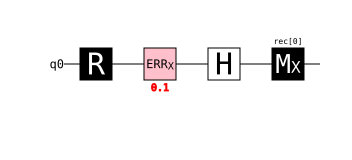

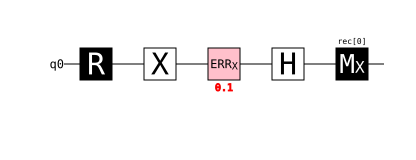

In [4]:
display(t_circ(noise = 0.1).diagram("timeline-svg"))
display(t_circ_with_x(noise = 0.1).diagram("timeline-svg"))

In [5]:
def mean_valu_calc(*, circuit_noiseless : stim.Circuit, circuit_noise : stim.Circuit, measure_observable : bool, num_shots : int = 50, 
                   num_experiments : int = 5) -> tuple[np.ndarray, np.ndarray]:
    
    """
    - Either have one observable including multiple measurements -> measure_observable = True

    - Or only have one measurement on final time -> measure_observable = False
    """

    # Define mean list
    noiseless_mean_array = np.empty(num_experiments, dtype=float)
    noise_mean_array = np.empty(num_experiments, dtype=float)

    # Runs per Experiment
    for k in range(num_experiments):

        # Compile Samplers and Sample shots without noise and with noise
        if measure_observable:
            sampler_noiseless = circuit_noiseless.compile_detector_sampler()
            sampler_noise = circuit_noise.compile_detector_sampler()
            noiseless_samples = sampler_noiseless.sample(shots = num_shots, append_observables = True)
            noise_samples = sampler_noise.sample(shots = num_shots, append_observables = True)

        else:
            sampler_noiseless = circuit_noiseless.compile_sampler()
            sampler_noise = circuit_noise.compile_sampler()
            noiseless_samples = sampler_noiseless.sample(shots = num_shots)
            noise_samples = sampler_noise.sample(shots = num_shots)

        # Converting Samples into +1 & -1 and adding them up
        noiseless_results = 0
        noise_results = 0

        for i,j in zip(noiseless_samples, noise_samples):
            if i[0] == False:
                noiseless_results += 1
            else:
                noiseless_results += -1
            if j[0] == False:
                noise_results += 1
            else:
                noise_results += -1

        # Creating mean value per shot
        noiseless_mean = noiseless_results / num_shots
        noise_mean = noise_results / num_shots

        # Appending in returnable variable to incoorperate all num_experiment values
        noise_mean_array[k] = noise_mean
        noiseless_mean_array[k] = noiseless_mean

    return noise_mean_array, noiseless_mean_array

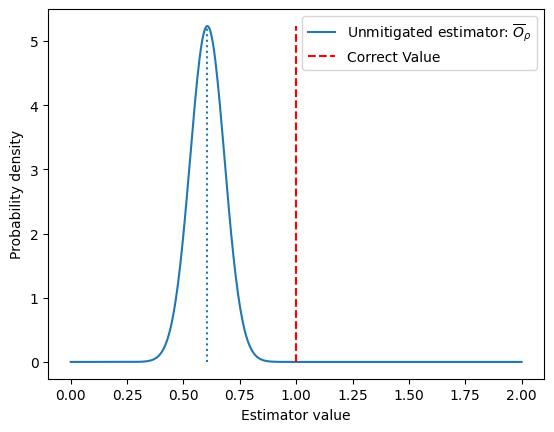

In [6]:
# Creating visual Comparison noiseless vs noisy
means_noisy, means_noiseless = mean_valu_calc(circuit_noise = t_circ(noise = 0.2), circuit_noiseless = t_circ(noise = 0), measure_observable = False, num_experiments = 20)

# Calc estimated mean and std. dev.
mu_nz,  sigma_nz  = norm.fit(means_noisy)

# Calc mean Value of gaussian curve
means_value = np.mean(means_noisy)
means_vlaue_expected = int(np.mean(means_noiseless))

# Create fitted PDFs
xmin = means_noisy.min()
xmax = means_noisy.max()
x = np.linspace(means_vlaue_expected - 1, means_vlaue_expected + 1, 400)

pdf_nz  = norm.pdf(x,  mu_nz,  sigma_nz)

# Plot the Curves
plt.plot(x, pdf_nz,  label=r"Unmitigated estimator: $\overline{O}_\rho$",  linestyle="-")
plt.xlabel("Estimator value")
plt.ylabel("Probability density")
plt.vlines(x = means_vlaue_expected, ymin = 0, ymax = max(pdf_nz) ,label = "Correct Value" , linestyles = "--", colors = "red")
plt.vlines(x = means_value, ymin = 0, ymax = max(pdf_nz) , linestyles = "dotted")
plt.legend()
plt.show()

In [7]:
def mit_estimator(number_samples : int = 50, number_shots : int = 50 , noise_value : float = 0.1) -> np.array:

    # Init measurement result vec
    meas_result = np.zeros(number_samples)

    # Initiating Circuit Sampler
    sampler_I = t_circ(noise = noise_value).compile_sampler()
    sampler_X = t_circ_with_x(noise = noise_value).compile_sampler()

    for i in range(number_samples):

        # Create random number
        current_rdm_nmbr = np.random.rand()

        # Init measurement result vec

        # Define important variables
        q = -noise_value/(1 - (2*noise_value))
        gamma = abs(1 - q) + abs(q)
        prob_I = (abs(1-q))/gamma
        prob_X = abs(q)/gamma
        sgn_I = math.copysign(1, 1-q)
        sgn_X = math.copysign(1, q)

        # Check which circuit should be sampled from
        if current_rdm_nmbr < prob_I:

            # Sample from Identity Crcuit
            samples = sampler_I.sample(shots = number_shots)

            mean_result = 0

            # Calc mean for this sample
            for k in samples:
                if k[0] == False:
                    mean_result += 1 * sgn_I * gamma
                else:
                    mean_result += -1 * sgn_I * gamma

            meas_result[i] = mean_result/(number_shots)

        else:

            #Sample from changed Circuit with additional Gate
            samples = sampler_X.sample(shots = number_shots)

            mean_result = 0

            # Calc mean for this sample
            for k in samples:
                if k[0] == False:
                    mean_result += 1 * sgn_X * gamma
                else:
                    mean_result += -1 * sgn_X * gamma

            meas_result[i] = mean_result/(number_shots)

    return meas_result

In [8]:
mit_estimator(number_samples = 50, number_shots = 10, noise_value = 0.2)

array([1.        , 1.        , 0.66666667, 1.        , 0.33333333,
       0.33333333, 1.        , 1.33333333, 0.66666667, 1.33333333,
       1.33333333, 0.66666667, 1.        , 0.33333333, 1.        ,
       1.33333333, 1.        , 1.33333333, 1.        , 0.66666667,
       1.        , 1.66666667, 0.66666667, 0.66666667, 1.        ,
       0.66666667, 1.33333333, 1.        , 0.66666667, 1.        ,
       0.66666667, 1.33333333, 1.33333333, 1.        , 1.        ,
       1.        , 0.33333333, 0.33333333, 0.33333333, 0.66666667,
       1.        , 1.33333333, 1.        , 1.33333333, 1.        ,
       0.33333333, 0.66666667, 1.        , 1.        , 1.        ])

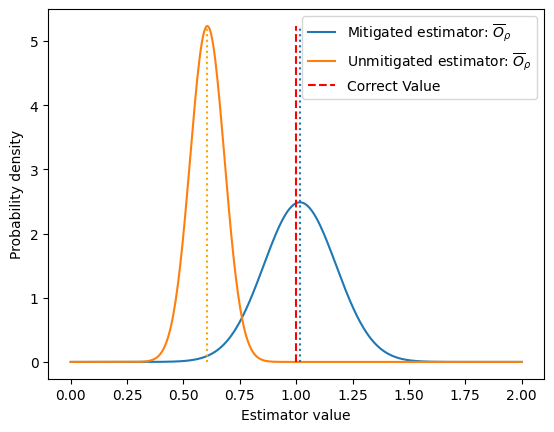

In [9]:
# Calc estimated mean and std. dev.
means_mitigated = mit_estimator(number_samples = 20, number_shots = 50, noise_value = 0.2)

# calc bell curve
mu_nz_mit,  sigma_nz_mit  = norm.fit(means_mitigated)

# Calc mean Value of gaussian curve
means_value_mit = np.mean(means_mitigated)
means_value = np.mean(means_noisy)
means_vlaue_expected = int(np.mean(means_noiseless))

# Create fitted PDFs
xmin = means_noisy.min()
xmax = means_noisy.max()
x = np.linspace(means_vlaue_expected - 1, means_vlaue_expected + 1, 400)

pdf_nz_mit  = norm.pdf(x,  mu_nz_mit,  sigma_nz_mit)

# Plot the Curves
plt.plot(x, pdf_nz_mit,  label=r"Mitigated estimator: $\overline{O}_\rho$",  linestyle="-")
plt.plot(x, pdf_nz,  label=r"Unmitigated estimator: $\overline{O}_\rho$",  linestyle="-")
plt.xlabel("Estimator value")
plt.ylabel("Probability density")
plt.vlines(x = means_vlaue_expected, ymin = 0, ymax = max(pdf_nz) ,label = "Correct Value" , linestyles = "--", colors = "red")
plt.vlines(x = means_value_mit, ymin = 0, ymax = max(pdf_nz) , linestyles = "dotted")
plt.vlines(x = means_value, ymin = 0, ymax = max(pdf_nz) , linestyles = "dotted", colors = "orange")
plt.legend()
plt.show()

In [ ]:
def t2_circ(noise : float = 0):

    t_circuit = stim.Circuit()

    # Appending Reset
    t_circuit.append("RZ", [i for i in range(3)])

    # Appending Noise
    if noise > 0:
        t_circuit.append("DEPOLARIZE1", [i for i in range(3)], noise)

    # Append Hadarmard
    t_circuit.append("H", [0])

    if noise > 0:
        t_circuit.append("DEPOLARIZE1", [0], noise)

    # Appending CX gates
    for i in range(1,3,1):
        t_circuit.append("CX", [0,i])
        if noise > 0:
            t_circuit.append("DEPOLARIZE2", [0,i], noise)

    #if noise > 0:
        #t_circuit.append("X_ERROR", [i for i in range(3)], noise)

    # Appending Measurement
    t_circuit.append("MX", [i for i in range(3)])

    # Adding Observable
    t_circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(i) for i in range(-1,-4,-1)], [0])

    return t_circuit

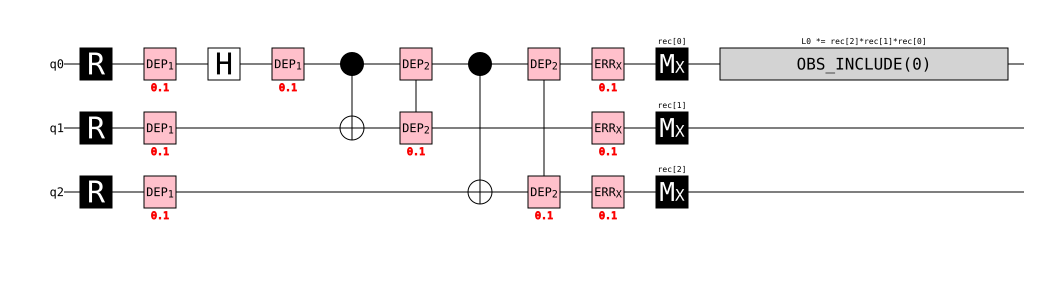

In [17]:
display(t2_circ(noise = 0.1).diagram("timeline-svg"))

As this is the GHZ state and we meassure the Operator ZZZ we expect the following -> either +1 or -1 with 50/50 chance
-> So tr($\lambda\rho$) = 0

In [18]:
sampler = t2_circ(noise = 0.0).compile_detector_sampler()
samples = sampler.sample(shots = 1, append_observables = True)

samples

array([[False]])

In [21]:
mc_estimator(circuit = t2_circ(noise = 0.1), circuit_noiseless = t2_circ(noise = 0), number_samples = 50, number_shots = 50)

IndexError: list index out of range

In [14]:
N = 2_000

vals = mc_estimator(circuit = t2_circ(noise = 0.1), 
                               circuit_noiseless = t2_circ(noise = 0), number_samples = N, number_shots = 1)

# unbiased estimate of the ideal expectation
mu_hat = float(np.mean(vals))

# Variance
var_hat = np.var(vals, ddof=1)    

# Std. mean error
se_hat  = np.sqrt(var_hat / N)

print(mu_hat, var_hat, se_hat)

0.9276986099926476 19.234051732426696 0.09806643598200838


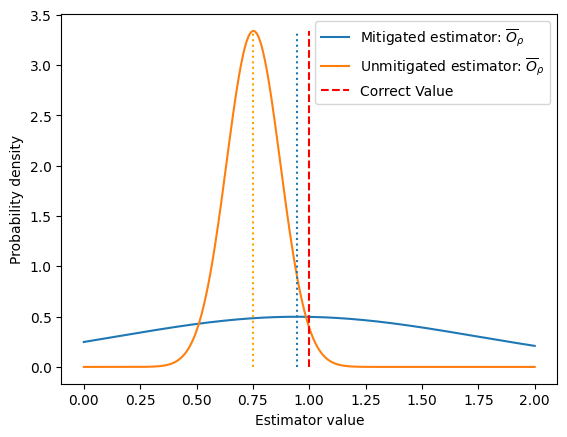

In [15]:
# Calc estimated mean and std. dev.
means_mitigated = mc_estimator(circuit = t2_circ(noise = 0.1), circuit_noiseless = t2_circ(noise = 0), 
                               number_samples = 8000, number_shots = 30)

# Creating visual Comparison noiseless vs noisy
means_noisy, means_noiseless = mean_valu_calc(circuit_noise = t2_circ(noise = 0.1), circuit_noiseless = t2_circ(noise = 0), 
                                              measure_observable = True, num_experiments = 1000, num_shots = 30)

# Calc estimated mean and std. dev.
mu_nz,  sigma_nz  = norm.fit(means_noisy)
pdf_nz  = norm.pdf(x,  mu_nz,  sigma_nz)

# calc bell curve
mu_nz_mit,  sigma_nz_mit  = norm.fit(means_mitigated)

# Calc mean Value of gaussian curve
means_value_mit = np.mean(means_mitigated)
means_value = np.mean(means_noisy)
means_vlaue_expected = int(np.mean(means_noiseless))

# Create fitted PDFs
xmin = means_noisy.min()
xmax = means_noisy.max()
x = np.linspace(means_vlaue_expected - 1, means_vlaue_expected + 1, 400)

pdf_nz_mit  = norm.pdf(x,  mu_nz_mit,  sigma_nz_mit)

# Plot the Curves
plt.plot(x, pdf_nz_mit,  label=r"Mitigated estimator: $\overline{O}_\rho$",  linestyle="-")
plt.plot(x, pdf_nz,  label=r"Unmitigated estimator: $\overline{O}_\rho$",  linestyle="-")
plt.xlabel("Estimator value")
plt.ylabel("Probability density")
plt.vlines(x = means_vlaue_expected, ymin = 0, ymax = max(pdf_nz) ,label = "Correct Value" , linestyles = "--", colors = "red")
plt.vlines(x = means_value_mit, ymin = 0, ymax = max(pdf_nz) , linestyles = "dotted")
plt.vlines(x = means_value, ymin = 0, ymax = max(pdf_nz) , linestyles = "dotted", colors = "orange")
plt.legend()
plt.show()